# Normalization

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
wine = pd.read_csv(r"/Users/rahulkumarghosh/Documents/100_DAYS_ML/Day_25/Wine dataset.csv")

In [4]:
wine

,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [8]:
wine = wine[["class", "Alcohol", "Malic acid"]]
wine.columns = ["class", "Alcohol", "Malic_acid"]

In [9]:
wine

,class,Alcohol,Malic_acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

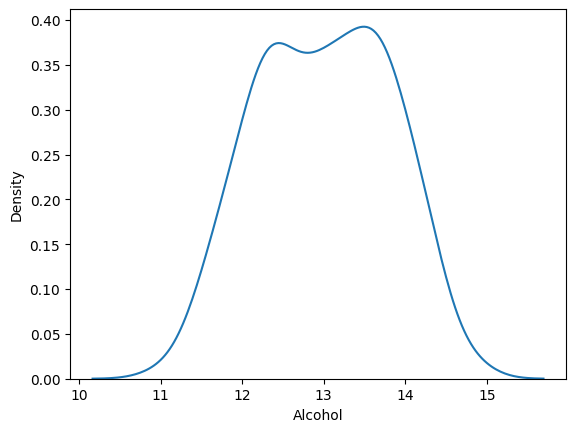

In [10]:
sns.kdeplot(wine["Alcohol"])

<Axes: xlabel='Malic_acid', ylabel='Density'>

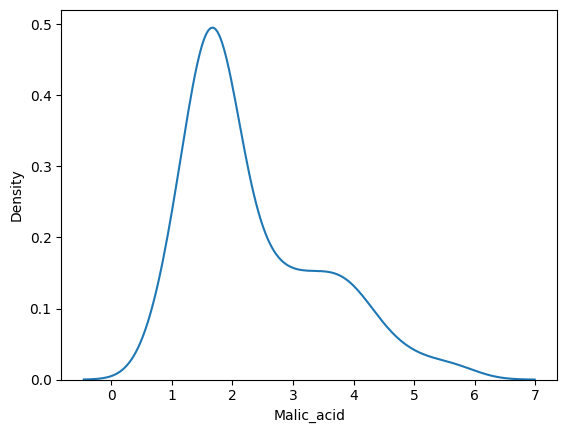

In [13]:
sns.kdeplot(wine["Malic_acid"])

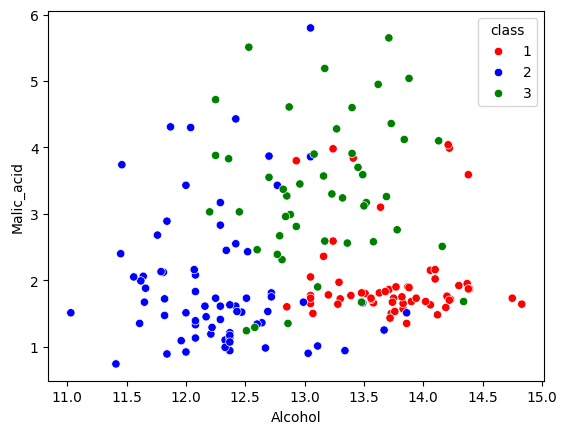

In [16]:
color_dict = {1: "red", 2: "blue", 3: "green"}

sns.scatterplot(
    data=wine,
    x="Alcohol",
    y="Malic_acid",
    hue="class",
    palette=color_dict
)

plt.show()

In [23]:
from sklearn.model_selection import train_test_split
X = wine.drop("class", axis=1)
y = wine["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=0
)

In [27]:
X_train.shape

(124, 2)

In [32]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [35]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaler = pd.DataFrame(X_train_scaled, columns=X_test.columns)

In [37]:
np.round(X_train_scaled.describe(),1)

,Alcohol,Malic_acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


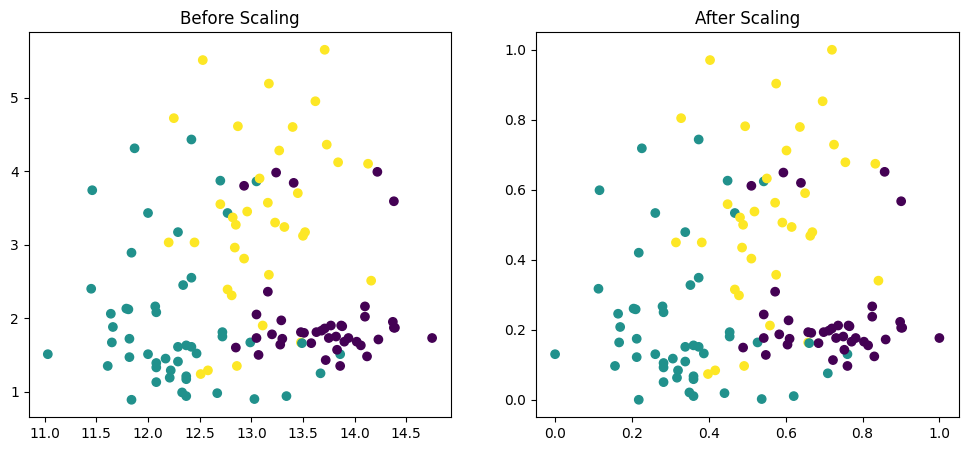

In [41]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(X_train["Alcohol"],X_train["Malic_acid"],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled["Alcohol"], X_train_scaled["Malic_acid"], c=y_train)
ax2.set_title("After Scaling")
plt.show()

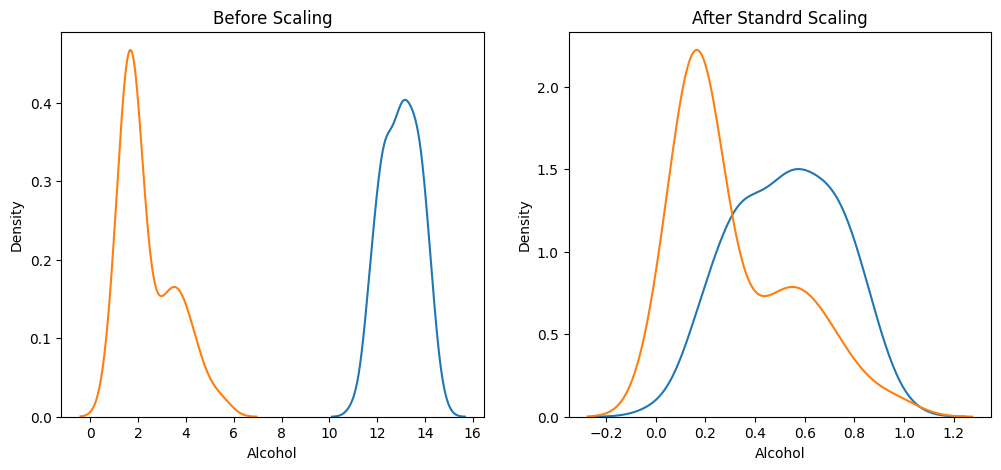

In [43]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12,5))

#before scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train["Alcohol"], ax=ax1)
sns.kdeplot(X_train["Malic_acid"], ax=ax1)

# after scaling
ax2.set_title("After Standrd Scaling")
sns.kdeplot(X_train_scaled["Alcohol"],ax=ax2)
sns.kdeplot(X_train_scaled["Malic_acid"], ax=ax2)
plt.show()